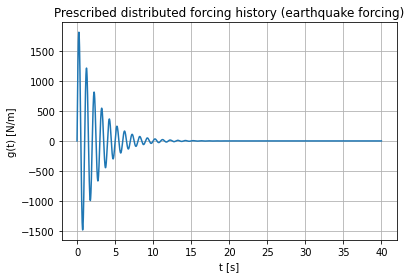

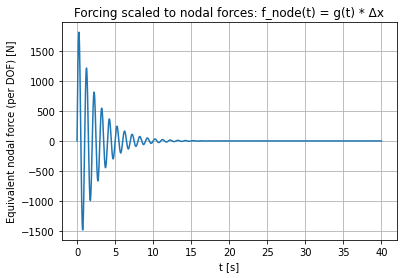

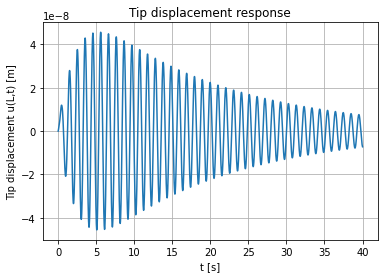

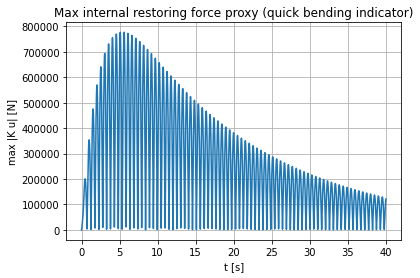

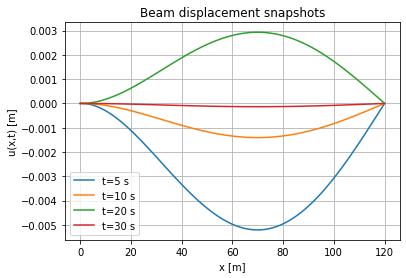

---- Sanity summary ----
dx = 1.0 m
First 3 natural frequencies [Hz] = [0.22166915 1.38900695 3.88838036]
Peak |g(t)| [N/m] = 1813.3427397037192
Peak approx total lateral force |g|*L [N] ~ 217601.1287644463
Peak tip displacement [m] = 4.5657292231867875e-08


In [19]:
# --- AE370 Group Project 2: EB beam (semi-discrete) + Newmark-beta time integration ---
# Fixes included:
#   1) Forcing units: g(t) treated as distributed load [N/m] -> converted to nodal force [N] via * dx
#   2) Nodal mass: lumped nodal mass uses (rho*A) [kg/m] * dx [m] = [kg]
#   3) Reasonable default forcing magnitude + damping setup (Rayleigh damping from target modal zeta)
#   4) Clear plots (earthquake forcing, tip displacement, beam shape snapshots, param sweeps)
#   5) Cantilever-ish BCs: base displacement & slope ~ 0 enforced by fixing first two nodes (u0=u1=0)
#      free end moment/shear ~ 0 enforced using ghost-node elimination for the last two stencils

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0) Helper: build K for EB 4th-derivative with cantilever-ish BCs
# -----------------------------
def build_K_EB_cantilever_like(E, I, L, n_el):
    """
    Build stiffness matrix K so that (EI * u_xxxx) is approximated by 5-pt stencil.
    BCs:
      - "clamped" at x=0 approximated by u0=0 and u1=0 (displacement & slope ~0)
      - "free" at x=L via u_xx(L)=0 and u_xxx(L)=0 implemented using ghost elimination
    Returns:
      K (ndof x ndof), dx, x, free_dofs
    """
    # n_el: number of elements; number of nodes is n_el+1
    n_nodes = n_el + 1                                  # number of spatial nodes
    x = np.linspace(0.0, L, n_nodes)                    # node coordinates [m]
    dx = x[1] - x[0]                                    # grid spacing [m]
    EI = E * I                                          # bending stiffness [N*m^2]

    # We'll build K on the full node set, then eliminate fixed DOFs
    K_full = np.zeros((n_nodes, n_nodes), dtype=float)  # full stiffness matrix

    # Convenience scalar for the 5-point fourth-derivative stencil
    kfac = EI / (dx**4)                                 # [N/m^2] * (unit conversion depends on discretization)

    # Interior stencil (standard): u''''(x_j) ~ (u_{j-2} - 4u_{j-1} + 6u_j - 4u_{j+1} + u_{j+2}) / dx^4
    # We'll apply this for j = 2..n_nodes-3 (i.e. nodes with full 5-point support)
    for j in range(2, n_nodes - 2):
        K_full[j, j-2] += 1.0 * kfac
        K_full[j, j-1] += -4.0 * kfac
        K_full[j, j]   += 6.0 * kfac
        K_full[j, j+1] += -4.0 * kfac
        K_full[j, j+2] += 1.0 * kfac

    # --- Free end conditions using ghost elimination ---
    # Let last physical node index be N = n_nodes-1
    N = n_nodes - 1

    # Enforce u_xx(L)=0:
    #   (u_{N-1} - 2u_N + u_{N+1})/dx^2 = 0  ->  u_{N+1} = 2u_N - u_{N-1}
    # Enforce u_xxx(L)=0 (one common centered form at N):
    #   (u_{N-2} - 2u_{N-1} + 2u_{N+1} - u_{N+2})/(2 dx^3) = 0
    # -> u_{N+2} = u_{N-2} - 2u_{N-1} + 2u_{N+1}
    # Substitute u_{N+1}:
    # -> u_{N+2} = u_{N-2} - 2u_{N-1} + 2(2u_N - u_{N-1}) = u_{N-2} - 4u_{N-1} + 4u_N

    # Now we need u'''' at nodes near the end where stencil would reference N+1/N+2.
    # We'll overwrite the last two rows j=N-1 and j=N with stencils where ghosts are eliminated.

    # For j = N-1: stencil needs u_{N+1}
    # u''''_{N-1} ~ (u_{N-3} - 4u_{N-2} + 6u_{N-1} - 4u_N + u_{N+1}) / dx^4
    # Substitute u_{N+1} = 2u_N - u_{N-1}
    # => coefficients:
    #   u_{N-3}:  1
    #   u_{N-2}: -4
    #   u_{N-1}:  6 + (-1) = 5
    #   u_N:     -4 + 2 = -2
    j = N - 1
    K_full[j, N-3] +=  1.0 * kfac
    K_full[j, N-2] += -4.0 * kfac
    K_full[j, N-1] +=  5.0 * kfac
    K_full[j, N]   += -2.0 * kfac

    # For j = N: stencil needs u_{N+1} and u_{N+2}
    # u''''_N ~ (u_{N-2} - 4u_{N-1} + 6u_N - 4u_{N+1} + u_{N+2}) / dx^4
    # Substitute:
    #   u_{N+1} = 2u_N - u_{N-1}
    #   u_{N+2} = u_{N-2} - 4u_{N-1} + 4u_N
    # => u_{N-2}: 1 + 1 = 2
    #    u_{N-1}: -4 + 4 + (-4) = -4  (careful: -4u_{N+1} gives +4u_{N-1}, and u_{N+2} gives -4u_{N-1})
    #    u_N: 6 + (-8) + 4 = 2
    j = N
    K_full[j, N-2] +=  2.0 * kfac
    K_full[j, N-1] += -4.0 * kfac
    K_full[j, N]   +=  2.0 * kfac

    # --- Clamped-ish base: enforce u(0)=0 and u_x(0)=0 via u0=0 and u1=0 ---
    fixed = np.array([0, 1], dtype=int)                        # fixed DOF indices
    free_dofs = np.array([i for i in range(n_nodes) if i not in fixed], dtype=int)

    # Reduce K to free DOFs
    K = K_full[np.ix_(free_dofs, free_dofs)]                    # reduced stiffness matrix
    x_free = x[free_dofs]                                       # free node locations

    return K, dx, x, free_dofs, x_free


# -----------------------------
# 1) Helper: Rayleigh damping from target modal damping ratios
# -----------------------------
def rayleigh_from_two_modes(omega1, omega2, zeta1=0.02, zeta2=0.02):
    """
    Solve for Rayleigh coefficients alpha_R, beta_R in:
      C = alpha_R * M + beta_R * K
    with modal damping ratio relation:
      zeta(omega) = (1/2) * (alpha_R/omega + beta_R * omega)
    Using two points (omega1,zeta1) and (omega2,zeta2).
    """
    # Build linear system for [alpha_R, beta_R]
    # 2*zeta = alpha/omega + beta*omega
    A = np.array([[1.0/omega1, omega1],
                  [1.0/omega2, omega2]], dtype=float)
    b = np.array([2.0*zeta1, 2.0*zeta2], dtype=float)
    alpha_R, beta_R = np.linalg.solve(A, b)                    # Rayleigh coefficients
    return alpha_R, beta_R


# -----------------------------
# 2) Helper: Generalized eigenvalues for (K, M) with diagonal M
# -----------------------------
def natural_frequencies(K, M_diag, n_modes=6):
    """
    Solve K phi = lambda M phi, with M diagonal stored as M_diag.
    Returns omega (rad/s) and mode shapes (columns).
    """
    # Convert to standard eigenproblem: (M^{-1} K) phi = lambda phi
    Minv = np.diag(1.0 / M_diag)                               # inverse mass matrix
    A = Minv @ K                                               # system matrix
    # Use symmetric eigen-solver if A is symmetric (it should be close here)
    lam, V = np.linalg.eig(A)                                  # eigenvalues and eigenvectors
    lam = np.real(lam)                                         # discard tiny imaginary numerical noise
    # Keep positive eigenvalues (physical)
    idx = np.argsort(lam)
    lam_sorted = lam[idx]
    V_sorted = V[:, idx]
    lam_pos = lam_sorted[lam_sorted > 1e-12]
    V_pos = V_sorted[:, lam_sorted > 1e-12]
    omega = np.sqrt(lam_pos)                                   # omega_k = sqrt(lambda_k)
    return omega[:n_modes], V_pos[:, :n_modes]


# -----------------------------
# 3) Earthquake forcing: distributed load g(t) [N/m]
# -----------------------------
def forcing_distributed(t, F0, omega_f, alpha_f):
    """
    Distributed lateral forcing per unit length [N/m]:
      g(t) = F0 * exp(-alpha_f * t) * sin(omega_f * t)
    """
    return F0 * np.exp(-alpha_f * t) * np.sin(omega_f * t)


# -----------------------------
# 4) Newmark-beta integrator (beta=1/4, gamma=1/2 by default)
# -----------------------------
from scipy.linalg import cho_factor, cho_solve  # ADD THIS IMPORT

def newmark_beta(M_diag, C, K, f_of_t, t, u0, v0, beta=1/4, gamma=1/2):
    ndof = len(M_diag)
    nt = len(t)
    dt = t[1] - t[0]

    U = np.zeros((nt, ndof), dtype=float)
    V = np.zeros((nt, ndof), dtype=float)
    Aacc = np.zeros((nt, ndof), dtype=float)

    U[0, :] = u0
    V[0, :] = v0

    f0 = f_of_t(t[0])
    rhs0 = f0 - (C @ v0) - (K @ u0)
    Aacc[0, :] = rhs0 / M_diag

    a0 = 1.0 / (beta * dt * dt)
    a1 = gamma / (beta * dt)
    a2 = 1.0 / (beta * dt)
    a3 = 1.0 / (2.0 * beta) - 1.0
    a4 = gamma / beta - 1.0
    a5 = dt * (gamma / (2.0 * beta) - 1.0)

    K_eff = K + np.diag(a0 * M_diag) + a1 * C

    # >>> SPEEDUP: factorize once, solve many <<<
    Keff_fac = cho_factor(K_eff, overwrite_a=False, check_finite=False)

    for n in range(nt - 1):
        tn1 = t[n + 1]
        fn1 = f_of_t(tn1)

        termM = M_diag * (a0 * U[n, :] + a2 * V[n, :] + a3 * Aacc[n, :])
        termC = C @ (a1 * U[n, :] + a4 * V[n, :] + a5 * Aacc[n, :])
        f_eff = fn1 + termM + termC

        # U[n + 1, :] = np.linalg.solve(K_eff, f_eff)  # OLD
        U[n + 1, :] = cho_solve(Keff_fac, f_eff, check_finite=False)  # NEW

        Aacc[n + 1, :] = a0 * (U[n + 1, :] - U[n, :]) - a2 * V[n, :] - a3 * Aacc[n, :]
        V[n + 1, :] = V[n, :] + dt * ((1.0 - gamma) * Aacc[n, :] + gamma * Aacc[n + 1, :])

    return U, V, Aacc
# def newmark_beta(M_diag, C, K, f_of_t, t, u0, v0, beta=1/4, gamma=1/2):
#     """
#     Solve: M u_ddot + C u_dot + K u = f(t)
#     with Newmark-beta time integration.
#     Inputs:
#       M_diag : diagonal entries of M (lumped mass) [kg]
#       C      : damping matrix [N*s/m]
#       K      : stiffness matrix [N/m]
#       f_of_t : function f(tk) returning force vector [N] (size ndof)
#       t      : time array [s]
#       u0     : initial displacement vector [m]
#       v0     : initial velocity vector [m/s]
#     Returns:
#       U, V, A arrays with shape (nt, ndof)
#     """
#     # Dimensions
#     ndof = len(M_diag)                                         # number of free DOFs
#     nt = len(t)                                                # number of time points
#     dt = t[1] - t[0]                                            # time step size [s]

#     # Allocate output arrays
#     U = np.zeros((nt, ndof), dtype=float)                      # displacement history [m]
#     V = np.zeros((nt, ndof), dtype=float)                      # velocity history [m/s]
#     Aacc = np.zeros((nt, ndof), dtype=float)                   # acceleration history [m/s^2]

#     # Initial conditions
#     U[0, :] = u0                                                # set initial displacement
#     V[0, :] = v0                                                # set initial velocity

#     # Compute initial acceleration from equilibrium:
#     #   M a0 = f(t0) - C v0 - K u0
#     f0 = f_of_t(t[0])                                           # force at initial time [N]
#     rhs0 = f0 - (C @ v0) - (K @ u0)                             # right-hand side [N]
#     Aacc[0, :] = rhs0 / M_diag                                  # since M is diagonal: a = rhs / M_diag

#     # Newmark constants
#     a0 = 1.0 / (beta * dt * dt)                                 # coefficient [1/s^2]
#     a1 = gamma / (beta * dt)                                    # coefficient [1/s]
#     a2 = 1.0 / (beta * dt)                                      # coefficient [1/s]
#     a3 = 1.0 / (2.0 * beta) - 1.0                               # coefficient [-]
#     a4 = gamma / beta - 1.0                                     # coefficient [-]
#     a5 = dt * (gamma / (2.0 * beta) - 1.0)                      # coefficient [s]

#     # Effective stiffness matrix: K_eff = K + a0*M + a1*C
#     # Since M is diagonal, a0*M is diagonal too.
#     K_eff = K + np.diag(a0 * M_diag) + a1 * C                   # [N/m]

#     # Pre-factorization (simple): use numpy solve each step (fine for ndof ~ O(100))
#     # Time stepping
#     for n in range(nt - 1):
#         tn1 = t[n + 1]                                          # next time [s]

#         # Effective force:
#         # f_eff = f_{n+1} + M*(a0*u_n + a2*v_n + a3*a_n) + C*(a1*u_n + a4*v_n + a5*a_n)
#         fn1 = f_of_t(tn1)                                       # force at tn1 [N]
#         termM = M_diag * (a0 * U[n, :] + a2 * V[n, :] + a3 * Aacc[n, :])   # [N]
#         termC = C @ (a1 * U[n, :] + a4 * V[n, :] + a5 * Aacc[n, :])        # [N]
#         f_eff = fn1 + termM + termC                             # [N]

#         # Solve for u_{n+1}
#         U[n + 1, :] = np.linalg.solve(K_eff, f_eff)             # displacement at tn1 [m]

#         # Back out acceleration and velocity
#         Aacc[n + 1, :] = a0 * (U[n + 1, :] - U[n, :]) - a2 * V[n, :] - a3 * Aacc[n, :]   # [m/s^2]
#         V[n + 1, :] = V[n, :] + dt * ((1.0 - gamma) * Aacc[n, :] + gamma * Aacc[n + 1, :])  # [m/s]

#     return U, V, Aacc


# ============================================================
# 5) Baseline run (sane defaults) + plots
# ============================================================

# --- Material / geometry parameters (edit these) ---
E = 25e9                 # Young's modulus [Pa] (e.g., concrete-ish scale)
rho = 2500.0             # density [kg/m^3]
L = 120.0                # building height / beam length [m]
A = 25.0                 # cross-sectional area [m^2]
I = 80.0                 # second moment of area [m^4]  (increase -> stiffer, higher frequencies)

# --- Spatial discretization ---
n_el = 120               # number of elements (nodes = n_el+1); keep moderate for speed
K, dx, x, free_dofs, x_free = build_K_EB_cantilever_like(E, I, L, n_el)

ndof = K.shape[0]        # number of free degrees of freedom

# --- Mass matrix (lumped diagonal) ---
m_line = rho * A         # mass per unit length [kg/m]
M_diag = (m_line * dx) * np.ones(ndof)   # lumped nodal mass [kg]

# --- Compute natural frequencies (undamped) ---
omega_modes, mode_shapes = natural_frequencies(K, M_diag, n_modes=6)  # [rad/s]
f_modes = omega_modes / (2.0 * np.pi)                                 # [Hz]

# --- Damping (Rayleigh): choose target damping ratios at two modes ---
zeta_target_1 = 0.02     # 2% damping (mode 1)
zeta_target_2 = 0.02     # 2% damping (mode 3)
omega1 = omega_modes[0]  # first natural frequency [rad/s]
omega2 = omega_modes[2] if len(omega_modes) >= 3 else omega_modes[1]  # pick a higher mode if available

alpha_R, beta_R = rayleigh_from_two_modes(omega1, omega2, zeta1=zeta_target_1, zeta2=zeta_target_2)

C = alpha_R * np.diag(M_diag) + beta_R * K     # damping matrix [N*s/m]

# --- Forcing parameters (distributed load g(t) in N/m) ---
F0 = 2.0e3               # forcing amplitude [N/m]  (start here; 2e5 N/m was huge)
omega_f = 2.0 * np.pi * 1.0   # forcing frequency [rad/s] (1 Hz)
alpha_f = 0.4            # exponential decay rate [1/s]

# --- Time discretization ---
T_end = 40.0             # simulation duration [s]
dt = 0.005               # time step [s] (keep small enough for accuracy in oscillatory response)
t = np.arange(0.0, T_end + dt, dt)    # time array [s]

# --- Force vector function f(t): convert distributed load [N/m] to nodal forces [N] via * dx ---
def f_of_t(tk):
    g_t = forcing_distributed(tk, F0, omega_f, alpha_f)         # distributed load [N/m]
    f_vec = (g_t * dx) * np.ones(ndof)                          # nodal force vector [N]
    return f_vec

# --- Initial conditions ---
u0 = np.zeros(ndof)        # initial displacement [m]
v0 = np.zeros(ndof)        # initial velocity [m/s]

# --- Integrate with Newmark-beta (average acceleration) ---
U, V, Acc = newmark_beta(M_diag, C, K, f_of_t, t, u0, v0, beta=1/4, gamma=1/2)

# --- Extract "tip" displacement (last free DOF corresponds to x=L) ---
tip_index = ndof - 1                                 # index for tip dof in reduced system
u_tip = U[:, tip_index]                              # tip displacement time history [m]

# --- Also compute approximate bending indicator (discrete curvature proxy at interior) ---
# For a quick bending proxy: use a second-difference near the base or max of |K u|:
internal_force = (K @ U.T).T                         # K*u(t) ~ internal restoring force [N]
max_internal_force = np.max(np.abs(internal_force), axis=1)  # max over DOFs [N]

# ============================================================
# 6) Plots (what the earthquake looks like, tip motion, shapes)
# ============================================================

# Plot 1: Earthquake forcing history g(t) [N/m] and equivalent nodal force [N]
g_hist = forcing_distributed(t, F0, omega_f, alpha_f)          # distributed load [N/m]
fnode_hist = g_hist * dx                                       # nodal force per DOF [N]

plt.figure()
plt.plot(t, g_hist)
plt.xlabel("t [s]")
plt.ylabel("g(t) [N/m]")
plt.title("Prescribed distributed forcing history (earthquake forcing)")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(t, fnode_hist)
plt.xlabel("t [s]")
plt.ylabel("Equivalent nodal force (per DOF) [N]")
plt.title("Forcing scaled to nodal forces: f_node(t) = g(t) * Δx")
plt.grid(True)
plt.show()

# Plot 2: Tip displacement vs time
plt.figure()
plt.plot(t, u_tip)
plt.xlabel("t [s]")
plt.ylabel("Tip displacement u(L,t) [m]")
plt.title("Tip displacement response")
plt.grid(True)
plt.show()

# Plot 3: Max internal restoring force vs time (units: N)
plt.figure()
plt.plot(t, max_internal_force)
plt.xlabel("t [s]")
plt.ylabel("max |K u| [N]")
plt.title("Max internal restoring force proxy (quick bending indicator)")
plt.grid(True)
plt.show()

# Plot 4: Beam shape snapshots at a few times (displacement vs x)
# Reconstruct full displacement vector (including fixed DOFs) for plotting
def reconstruct_full(u_reduced):
    u_full = np.zeros(len(x))                            # full nodal displacement [m]
    u_full[free_dofs] = u_reduced                        # insert reduced solution into free dofs
    u_full[0] = 0.0                                      # fixed base displacement
    u_full[1] = 0.0                                      # fixed base slope proxy
    return u_full

snap_times = [5.0, 10.0, 20.0, 30.0]                     # snapshot times [s]
plt.figure()
for ts in snap_times:
    k = int(ts / dt)                                     # index in time array
    u_full = reconstruct_full(U[k, :])                   # full beam displacement profile [m]
    plt.plot(x, u_full, label=f"t={ts:.0f} s")
plt.xlabel("x [m]")
plt.ylabel("u(x,t) [m]")
plt.title("Beam displacement snapshots")
plt.grid(True)
plt.legend()
plt.show()

# Print a small sanity summary (minimal)
print("---- Sanity summary ----")
print("dx =", dx, "m")
print("First 3 natural frequencies [Hz] =", f_modes[:3])
print("Peak |g(t)| [N/m] =", np.max(np.abs(g_hist)))
print("Peak approx total lateral force |g|*L [N] ~", np.max(np.abs(g_hist))*L)
print("Peak tip displacement [m] =", np.max(np.abs(u_tip)))


# ============================================================
# 7) RQ1 sweep: vary A and I -> natural frequency + peak tip displacement
# ============================================================

# A_factors = np.array([0.5, 0.75, 1.0, 1.25, 1.5])                # scaling for A
# I_factors = np.array([0.5, 0.75, 1.0, 1.25, 1.5])                # scaling for I

# f1_grid = np.zeros((len(A_factors), len(I_factors)))             # first natural frequency [Hz]
# utip_grid = np.zeros((len(A_factors), len(I_factors)))           # peak tip displacement [m]

# # Keep forcing fixed for RQ1 (as in your prompt)
# for ia, Af in enumerate(A_factors):
#     for ii, If in enumerate(I_factors):
#         A_test = A * Af                                           # varied area [m^2]
#         I_test = I * If                                           # varied inertia [m^4]

#         # rebuild K for new I (only stiffness changes with I here)
#         K_test, dx_test, x_test, free_test, _ = build_K_EB_cantilever_like(E, I_test, L, n_el)

#         # mass changes with A
#         m_line_test = rho * A_test                                 # [kg/m]
#         M_diag_test = (m_line_test * dx_test) * np.ones(K_test.shape[0])  # [kg]

#         # frequencies
#         omega_test, _ = natural_frequencies(K_test, M_diag_test, n_modes=3)
#         f1_grid[ia, ii] = omega_test[0] / (2.0*np.pi)              # [Hz]

#         # Rayleigh damping based on the *current* structure (same target zeta)
#         omega1_test = omega_test[0]
#         omega2_test = omega_test[2] if len(omega_test) >= 3 else omega_test[1]
#         alphaR_test, betaR_test = rayleigh_from_two_modes(omega1_test, omega2_test,
#                                                           zeta1=zeta_target_1, zeta2=zeta_target_2)
#         C_test = alphaR_test * np.diag(M_diag_test) + betaR_test * K_test

#         # forcing scaled with dx_test
#         def f_of_t_test(tk):
#             g_tk = forcing_distributed(tk, F0, omega_f, alpha_f)   # [N/m]
#             return (g_tk * dx_test) * np.ones(K_test.shape[0])      # [N]

#         # integrate (shorter for sweep to keep it fast)
#         t_sweep = np.arange(0.0, 25.0 + dt, dt)
#         U_test, _, _ = newmark_beta(M_diag_test, C_test, K_test, f_of_t_test,
#                                     t_sweep, np.zeros(K_test.shape[0]), np.zeros(K_test.shape[0]),
#                                     beta=1/4, gamma=1/2)

#         utip_grid[ia, ii] = np.max(np.abs(U_test[:, -1]))          # peak tip displacement [m]

# # Plot RQ1 results: first natural frequency surface and peak tip displacement surface
# plt.figure()
# for ia, Af in enumerate(A_factors):
#     plt.plot(I_factors, f1_grid[ia, :], marker='o', label=f"A x {Af}")
# plt.xlabel("I scaling factor [-]")
# plt.ylabel("First natural frequency f1 [Hz]")
# plt.title("RQ1: Effect of A and I on first natural frequency")
# plt.grid(True)
# plt.legend()
# plt.show()

# plt.figure()
# for ia, Af in enumerate(A_factors):
#     plt.plot(I_factors, utip_grid[ia, :], marker='o', label=f"A x {Af}")
# plt.xlabel("I scaling factor [-]")
# plt.ylabel("Peak tip displacement [m]")
# plt.title("RQ1: Effect of A and I on peak tip displacement (forcing fixed)")
# plt.grid(True)
# plt.legend()
# plt.show()


# # ============================================================
# # 8) RQ2 sweep: vary forcing (F0, omega_f, alpha_f) with structure fixed
# # ============================================================

# freq_hz_list = np.linspace(0.2, 3.0, 12)                          # forcing frequencies [Hz]
# F0_list = np.array([5e2, 1e3, 2e3, 5e3])                          # forcing amplitudes [N/m]
# alpha_list = np.array([0.1, 0.3, 0.6])                            # decay rates [1/s]

# # We'll examine peak tip displacement vs forcing frequency for a few amplitudes (alpha fixed to baseline)
# plt.figure()
# for F0_try in F0_list:
#     peak_vs_freq = []
#     for fhz in freq_hz_list:
#         omega_try = 2.0*np.pi*fhz                                 # [rad/s]

#         def f_of_t_rq2(tk):
#             g_tk = forcing_distributed(tk, F0_try, omega_try, alpha_f)  # [N/m]
#             return (g_tk * dx) * np.ones(ndof)                           # [N]

#         t_rq2 = np.arange(0.0, 25.0 + dt, dt)
#         U_rq2, _, _ = newmark_beta(M_diag, C, K, f_of_t_rq2,
#                                    t_rq2, np.zeros(ndof), np.zeros(ndof),
#                                    beta=1/4, gamma=1/2)
#         peak_vs_freq.append(np.max(np.abs(U_rq2[:, -1])))          # [m]

#     plt.plot(freq_hz_list, peak_vs_freq, marker='o', label=f"F0={F0_try:.0e} N/m")

# plt.axvline(f_modes[0], linestyle='--', label="f1 (structure)")
# plt.xlabel("Forcing frequency [Hz]")
# plt.ylabel("Peak tip displacement [m]")
# plt.title("RQ2: Peak tip displacement vs forcing frequency (amplitude sweep)")
# plt.grid(True)
# plt.legend()
# plt.show()

# import numpy as np
# import matplotlib.pyplot as plt

# # -----------------------------
# # Helper: steady-state amplitude
# # -----------------------------
# def steady_state_amp(t, y, f_hz, n_cycles_keep=8):
#     """
#     Estimate steady-state amplitude by taking half the peak-to-peak value
#     over the last n_cycles_keep cycles of the forcing.
#     """
#     if f_hz <= 0:
#         return np.max(np.abs(y))
#     T = 1.0 / f_hz
#     t_end = t[-1]
#     t_start = t_end - n_cycles_keep * T
#     mask = t >= t_start
#     y_ss = y[mask]
#     return 0.5 * (np.max(y_ss) - np.min(y_ss))

# # -----------------------------
# # Resonance scan settings
# # -----------------------------
# F0 = 2.0e3          # forcing amplitude [N/m] (if using distributed) or [N] if point load
# alpha_force = 0.40  # forcing decay [1/s]
# fmax = 8.0          # MUST exceed f4 to see that peak
# freq_hz = np.linspace(0.2, fmax, 120)

# # OPTIONAL: reduce damping to make peaks sharper/obvious (if your C is Rayleigh, scale it)
# damping_scale = 0.25     # try 1.0 for your original, 0.25 or 0.1 to see clearer peaks
# C_use = damping_scale * C

# # Choose a forcing type:
# use_tip_point_load = True  # True = point load at tip; False = uniform distributed load

# # Make time horizon long enough for steady-state to settle
# # Use ~30 cycles of the lowest frequency in the sweep
# fmin = freq_hz.min()
# Tmin = 1.0 / fmin
# T_end = 30.0 * Tmin     # long run so low-freq steady-state is captured
# t = np.arange(0.0, T_end + dt, dt)

# def g_time(tk, F0_val, omega_val, alpha_val):
#     # decaying sinusoid; if you want non-decaying, set alpha_val=0
#     return F0_val * np.sin(omega_val * tk) * np.exp(-alpha_val * tk)

# # peak_tip = []
# # for fhz in freq_hz:
# #     omega = 2.0 * np.pi * fhz

# #     if use_tip_point_load:
# #         # Tip point load: f(t) is [N] applied to the last DOF only
# #         def f_of_t(tk):
# #             f = np.zeros(ndof)                      # [N]
# #             f[-1] = g_time(tk, F0, omega, alpha_force)  # tip load [N]
# #             return f
# #     else:
# #         # Uniform distributed load: g(t) [N/m] -> nodal force [N] using dx
# #         def f_of_t(tk):
# #             g = g_time(tk, F0, omega, alpha_force)  # [N/m]
# #             return (g * dx) * np.ones(ndof)         # [N]

# #     U, _, _ = newmark_beta(M_diag, C_use, K, f_of_t,
# #                            t, np.zeros(ndof), np.zeros(ndof),
# #                            beta=1/4, gamma=1/2)

# #     tip = U[:, -1]  # tip displacement [m]
# #     amp = steady_state_amp(t, tip, fhz, n_cycles_keep=10)
# #     peak_tip.append(amp)

# # peak_tip = np.array(peak_tip)

# # # Find peak in scan
# # imax = np.argmax(peak_tip)
# # f_peak = freq_hz[imax]

# -----------------------------
# Plot: frequency response with natural frequency markers
# -----------------------------
# plt.figure()
# plt.plot(freq_hz, peak_tip, marker='o', markersize=3)
# for k in range(min(4, len(f_modes))):
#     plt.axvline(f_modes[k], linestyle='--', label=f"f{k+1}={f_modes[k]:.2f} Hz")
# plt.axvline(f_peak, linestyle=':', label=f"Empirical peak @ {f_peak:.2f} Hz")
# plt.xlabel("Forcing frequency [Hz]")
# plt.ylabel("Steady-state tip amplitude [m]")
# title_force = "tip point load" if use_tip_point_load else "uniform distributed load"
# plt.title(f"Resonance under prescribed forcing ({title_force})")
# plt.grid(True)
# plt.legend()
# plt.show()

Reference: n_el=240, dt=0.001, dx=0.5


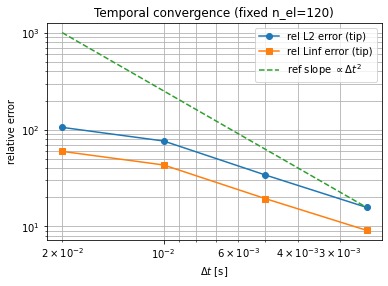

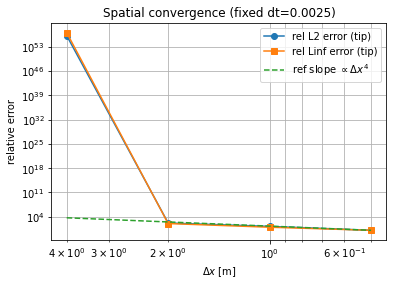

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Wrapper: run one case (n_el, dt) and return t and tip displacement
# -----------------------------
def run_case(n_el, dt,
             E=25e9, rho=2500.0, L=120.0, A=25.0, I=80.0,
             F0=2.0e3, f_force_hz=1.0, alpha_f=0.4,
             T_end=10.0,   # FAST MODE: was 40.0
             zeta_target_1=0.02, zeta_target_2=0.02,
             damping_scale=1.0,
             use_tip_point_load=False):

    K, dx, x, free_dofs, x_free = build_K_EB_cantilever_like(E, I, L, n_el)
    ndof = K.shape[0]

    m_line = rho * A
    M_diag = (m_line * dx) * np.ones(ndof)

    omega_modes, _ = natural_frequencies(K, M_diag, n_modes=6)
    omega1 = omega_modes[0]
    omega2 = omega_modes[2] if len(omega_modes) >= 3 else omega_modes[1]
    alpha_R, beta_R = rayleigh_from_two_modes(omega1, omega2, zeta1=zeta_target_1, zeta2=zeta_target_2)
    C = damping_scale * (alpha_R * np.diag(M_diag) + beta_R * K)

    t = np.arange(0.0, T_end + dt, dt)
    omega_f = 2.0 * np.pi * f_force_hz

    if use_tip_point_load:
        def f_of_t(tk):
            f = np.zeros(ndof)
            f[-1] = (F0) * np.exp(-alpha_f * tk) * np.sin(omega_f * tk)
            return f
    else:
        def f_of_t(tk):
            g = forcing_distributed(tk, F0, omega_f, alpha_f)  # [N/m]
            return (g * dx) * np.ones(ndof)                    # [N]

    u0 = np.zeros(ndof)
    v0 = np.zeros(ndof)

    U, V, Acc = newmark_beta(M_diag, C, K, f_of_t, t, u0, v0, beta=1/4, gamma=1/2)
    u_tip = U[:, -1]
    return t, u_tip, dx


def rel_L2_time_error(t_coarse, y_coarse, t_ref, y_ref):
    y_ref_on_coarse = np.interp(t_coarse, t_ref, y_ref)
    num = np.linalg.norm(y_coarse - y_ref_on_coarse)
    den = np.linalg.norm(y_ref_on_coarse) + 1e-30
    return num / den

def rel_Linf_time_error(t_coarse, y_coarse, t_ref, y_ref):
    y_ref_on_coarse = np.interp(t_coarse, t_ref, y_ref)
    num = np.max(np.abs(y_coarse - y_ref_on_coarse))
    den = np.max(np.abs(y_ref_on_coarse)) + 1e-30
    return num / den


# ============================================================
# Choose benchmark (reference) discretization (FAST MODE)
# ============================================================
n_ref  = 240     # was 480
dt_ref = 0.001   # was 0.0005
T_end  = 10.0    # was 40.0

use_tip_point_load = False
damping_scale = 1.0

tR, uR, dxR = run_case(n_ref, dt_ref, T_end=T_end,
                       use_tip_point_load=use_tip_point_load,
                       damping_scale=damping_scale)

print(f"Reference: n_el={n_ref}, dt={dt_ref}, dx={dxR:.5g}")


# ============================================================
# 1) Temporal convergence: vary dt with fixed spatial mesh
# ============================================================
n_fixed = 120  # was 240

dt_list = np.array([0.02, 0.01, 0.005, 0.0025])  # fewer points
err_dt_L2 = []
err_dt_Linf = []

for dt in dt_list:
    tC, uC, dxC = run_case(n_fixed, dt, T_end=T_end,
                           use_tip_point_load=use_tip_point_load,
                           damping_scale=damping_scale)
    err_dt_L2.append(rel_L2_time_error(tC, uC, tR, uR))
    err_dt_Linf.append(rel_Linf_time_error(tC, uC, tR, uR))

err_dt_L2 = np.array(err_dt_L2)
err_dt_Linf = np.array(err_dt_Linf)

plt.figure()
plt.loglog(dt_list, err_dt_L2, marker='o', label='rel L2 error (tip)')
plt.loglog(dt_list, err_dt_Linf, marker='s', label='rel Linf error (tip)')

dt0 = dt_list[-1]
e0 = err_dt_L2[-1]
plt.loglog(dt_list, e0*(dt_list/dt0)**2, linestyle='--', label=r'ref slope $\propto \Delta t^2$')

plt.gca().invert_xaxis()
plt.xlabel(r'$\Delta t$ [s]')
plt.ylabel('relative error')
plt.title(f'Temporal convergence (fixed n_el={n_fixed})')
plt.grid(True, which='both')
plt.legend()
plt.show()


# ============================================================
# 2) Spatial convergence: vary n_el with fixed dt
# ============================================================
dt_fixed = 0.0025  # was 0.00125

n_list = np.array([30, 60, 120, 240])  # fewer points (was up to 480)
dx_list = []
err_dx_L2 = []
err_dx_Linf = []

for n_el in n_list:
    tC, uC, dxC = run_case(n_el, dt_fixed, T_end=T_end,
                           use_tip_point_load=use_tip_point_load,
                           damping_scale=damping_scale)
    dx_list.append(dxC)
    err_dx_L2.append(rel_L2_time_error(tC, uC, tR, uR))
    err_dx_Linf.append(rel_Linf_time_error(tC, uC, tR, uR))

dx_list = np.array(dx_list)
err_dx_L2 = np.array(err_dx_L2)
err_dx_Linf = np.array(err_dx_Linf)

plt.figure()
plt.loglog(dx_list, err_dx_L2, marker='o', label='rel L2 error (tip)')
plt.loglog(dx_list, err_dx_Linf, marker='s', label='rel Linf error (tip)')

dx0 = dx_list[-1]
e0 = err_dx_L2[-1]
plt.loglog(dx_list, e0*(dx_list/dx0)**4, linestyle='--', label=r'ref slope $\propto \Delta x^4$')

plt.gca().invert_xaxis()
plt.xlabel(r'$\Delta x$ [m]')
plt.ylabel('relative error')
plt.title(f'Spatial convergence (fixed dt={dt_fixed})')
plt.grid(True, which='both')
plt.legend()
plt.show()